# Emittance Sample study


# Imports

In [1]:
# Ignore all warnings
import warnings
# warnings.filterwarnings("ignore")

import sys
# sys.path.append('C:\\Users\\Dylan\\SLAC') #parent directory containing emitopt module

import matplotlib.pyplot as plt
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

import pandas as pd
import torch

from xopt import Xopt
from xopt.vocs import VOCS
from xopt.generators.bayesian.bax_generator import BaxGenerator

from xopt.evaluator import Evaluator

from emitopt.analysis import compute_emit_bmag
from emitopt.sampling import draw_product_kernel_post_paths
from emitopt.algorithms import GridMinimizeEmitBmag

import time
import numpy as np
import random

# Use CUDA if available

In [2]:
if torch.cuda.is_available():
# if False:
    torch.set_default_tensor_type('torch.cuda.DoubleTensor')
    tkwargs = {"dtype": torch.double, "device": "cuda"}
    use_cuda = True
    print('Using cuda.')
else:
    torch.set_default_tensor_type('torch.DoubleTensor')
    use_cuda = False

C:\Users\dylan\anaconda3\envs\xopt-dev\Lib\site-packages\torch\__init__.py:1144: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at C:\Users\dev-admin\Desktop\build42\libtorch_1738271764196\work\torch\csrc\tensor\python_tensor.cpp:434.)
  _C._set_default_tensor_type(t)


In [3]:
torch.cuda.is_available()

False

# Notebook settings

In [4]:
ndim = 5 #number of input dimensions
noise = False #whether to add noise to the ground-truth beam size function outputs
thick_quad = True
meas_dim = 1 #input dimension for measurement parameter
n_obs_init = 25 #number of random initial observations for GP model
n_samples = 10 #number of posterior samples for BAX
n_iter = 1 #number of optimization steps for Xopt to take (after acquiring random initial data)
rand_seed = 3

#random seeds for reproducibility 
torch.manual_seed(rand_seed)
np.random.seed(rand_seed) #only affects initial random observations through Xopt
random.seed(rand_seed)

# Build test function from single-quadrupole optical beam size model 
Here we define a simple ground-truth beam size function for our optimization problem, where we attempt to find the location in tuning parameter space with minimal emittance. Note that the function "test_func" used to evaluate the ground-truth beam size function takes a dictionary as input and returns a dictionary as the output.

In [5]:
from pyemittance.emittance_calc import EmitCalc
from pyemittance.load_json_configs import load_configs
from pyemittance.simulation import BeamSim

CONFIG = load_configs('LCLS2_OTR0H04')
CONFIG['beamline_info']

q_len = CONFIG['beamline_info']['Lquad']
rmat_x = torch.tensor(CONFIG['beamline_info']['rMatx']).reshape(2,2)
rmat_y = torch.tensor(CONFIG['beamline_info']['rMaty']).reshape(2,2)
print(rmat_x)
print(rmat_y)

tensor([[1.0000, 2.2000],
        [0.0000, 1.0000]])
tensor([[1.0000, 2.2000],
        [0.0000, 1.0000]])


In [6]:
BUNCH_PARAMS0 = {
    'total_charge': 50e-12,
    'norm_emit_x': 1e-6,
    'norm_emit_y': 2e-6,
    'beta_x': 10,
    'alpha_x': -1,
    'beta_y': 11,
    'alpha_y': -2,
    'energy': 80e6,
    'species':'electron'
}
sim = BeamSim(bunch_params=BUNCH_PARAMS0, beamline_info=CONFIG['beamline_info'])


# define variables functions
var_names = ['x' + str(i) for i in range(ndim)]
meas_param = var_names[meas_dim]

from emitopt.utils import get_quad_scale_factor
scale_factor = get_quad_scale_factor(E=.08, q_len=q_len)

def measure_beamsize(input_dict):
    scale = 1.e3
    x_tuning = torch.tensor([])
    for key in input_dict.keys():
        if key != str(meas_param):
            x_tuning = torch.cat((x_tuning, torch.tensor([input_dict[key]])))
    rms_beamsizes0 = np.array(sim.beam_size_meas(input_dict[meas_param]))
    detuning_scale = 1. + 1*x_tuning.abs().sum().cpu()
    xrms, yrms = detuning_scale * rms_beamsizes0
    return {'xrms_sq': (float(xrms)*scale)**2.+5,
            'yrms_sq': (float(yrms)*scale)**2.+5} # mean-square beam sizes in mm squared

# Construct vocs

In [7]:
variables = {var_name: [-2,1] for var_name in var_names}
variables[meas_param] = [-3,3] #overwrite bounds for measurement parameter to capture minimum of single-quadrupole optical model

#construct vocs
vocs = VOCS(
    variables = variables,
    observables = ['xrms_sq', 'yrms_sq'],
)

print('variable_names =', vocs.variable_names)
print('meas_param =', "'" + meas_param + "'")
print('domain =\n', vocs.bounds.T)

variable_names = ['x0', 'x1', 'x2', 'x3', 'x4']
meas_param = 'x1'
domain =
 [[-2.  1.]
 [-3.  3.]
 [-2.  1.]
 [-2.  1.]
 [-2.  1.]]


In [8]:
def eval_true_emittance(x, use_bmag=False):
    emits = []
    bmags = []
    q = torch.linspace(-3,3,11)
    k = scale_factor*q
    ks = torch.stack((k,-k))
    rmats = torch.stack((rmat_x, rmat_y))
    for setting in x:
        bssx = []
        bssy = []
        input_dict = {name: float(setting[i]) for i, name in enumerate(vocs.variable_names)}
        for v in q.numpy():
            input_dict[meas_param] = v
            output_dict = measure_beamsize(input_dict)
            bssx += [output_dict['xrms_sq']]
            bssy += [output_dict['yrms_sq']]
        bss = torch.tensor([bssx, bssy])
        beta0 = torch.tensor([[10], [11]])
        alpha0 = torch.tensor([[-1], [-2]])
        emit, bmag, sig, is_valid = compute_emit_bmag(ks, bss, q_len, rmats, beta0=beta0, alpha0=alpha0, thick=True)
        emits += [torch.sqrt(emit[0]*emit[1])]
        bmags += [torch.sqrt(bmag[0].min()*bmag[1].min())]
    res = torch.tensor(emits)
    if use_bmag:
        res *= torch.tensor(bmags)
    return res
eval_true_emittance(torch.zeros(1,ndim), use_bmag=False)

tensor([0.3099])

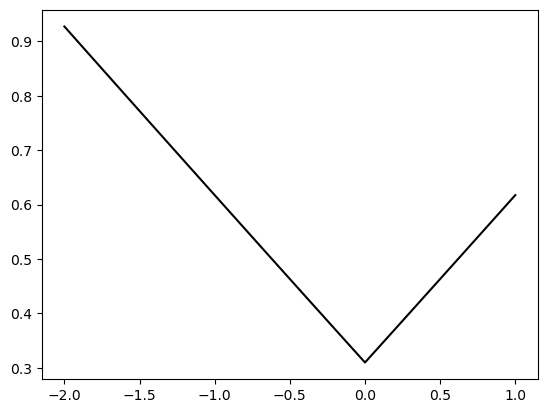

In [9]:
x = torch.zeros(100, ndim)
x[:,0] = torch.linspace(*vocs.bounds.T[0], 100)
plt.plot(x[:,0], eval_true_emittance(x, use_bmag=False), c='k')

# Prepare generator options.
In this example, we use a specialty covariance module (Matern x Quadratic kernel) for our beam size model.

In [10]:
from gpytorch.kernels import MaternKernel, PolynomialKernel, ScaleKernel
from gpytorch.priors.torch_priors import GammaPrior

from xopt.generators.bayesian.models.standard import StandardModelConstructor
from xopt.generators.bayesian.bax_generator import BaxGenerator
from emitopt.algorithms import ScipyMinimizeEmittanceXY

# prepare custom covariance module
tuning_dims = list(range(vocs.n_variables))
tuning_dims.remove(meas_dim)
covar_module_x = (MaternKernel(ard_num_dims=len(tuning_dims), 
                              active_dims=tuning_dims, 
                              lengthscale_prior=None) * 
                              PolynomialKernel(power=2, active_dims=[meas_dim])
                 )

scaled_covar_module_x = ScaleKernel(covar_module_x)#, outputscale_prior=GammaPrior(2.0, 0.15))
covar_module_y = (MaternKernel(ard_num_dims=len(tuning_dims), 
                              active_dims=tuning_dims, 
                              lengthscale_prior=None) * 
                              PolynomialKernel(power=2, active_dims=[meas_dim])
                 )
scaled_covar_module_y =  ScaleKernel(covar_module_y)#, outputscale_prior=GammaPrior(2.0, 0.15))

# prepare options for Xopt generator
covar_module_dict = {'xrms_sq': scaled_covar_module_x,
                     'yrms_sq': scaled_covar_module_y}

model_constructor = StandardModelConstructor(covar_modules=covar_module_dict, use_low_noise_prior=True)

In [11]:
from xopt.numerical_optimizer import LBFGSOptimizer, GridOptimizer
numerical_optimizer = LBFGSOptimizer(
                                    n_restarts=20,
                                    max_time=2)
# numerical_optimizer = GridOptimizer()

# Construct generator, evaluator, Xopt objects

In [12]:
# class DifferentialEvolutionEmitBmag(GridMinimizeEmitBmag):
#     name = "DifferentialEvolutionEmitBmag"

#     def get_execution_paths(self, model: ModelList, bounds: Tensor, tkwargs=None, verbose=False):
#         if not (self.x_key or self.y_key):
#             raise ValueError("must provide a key for x, y, or both.")
#         if (self.x_key and self.rmat_x is None) or (self.y_key and self.rmat_y is None):
#             raise ValueError("must provide rmat for each transverse dimension (x/y) being modeled.")
    
#         tkwargs = tkwargs if tkwargs else {"dtype": torch.double, "device": "cpu"}

#         temp_id = self.meas_dim + 1
#         tuning_domain = torch.cat((bounds.T[: self.meas_dim], bounds.T[temp_id:]))

#         tuning_bounds = tuning_domain.T
        
#         cpu_models = [copy.deepcopy(m).cpu() for m in model.models]

#         sample_funcs_list = []
#         for cpu_model in cpu_models:
#             if type(cpu_model.covar_module.base_kernel) == ProductKernel:
#                 sample_funcs = draw_product_kernel_post_paths(cpu_model, n_samples=self.n_samples)
#             if type(cpu_model.covar_module.base_kernel) == MaternKernel:
#                 sample_funcs = draw_matheron_paths(cpu_model, sample_shape=torch.Size([self.n_samples]))
#             sample_funcs_list += [sample_funcs]
        
        

In [13]:
from emitopt.algorithms import DifferentialEvolutionEmitBmag

#Prepare Algorithm
algo_kwargs = {
        'x_key': 'xrms_sq',
        'y_key': 'yrms_sq',
        'scale_factor': scale_factor,
        'q_len': q_len,
        'rmat_x': rmat_x,
        'rmat_y': rmat_y,
        'twiss0_x': torch.tensor([10., -1.]),
        'twiss0_y': torch.tensor([11., -2.]),
        'n_samples': n_samples,
        'meas_dim': meas_dim,
        'n_steps_measurement_param': 3,
        'thick_quad': thick_quad,
        'n_grid_points': 3,
        'use_bmag': False,
}
algo = DifferentialEvolutionEmitBmag(**algo_kwargs)
# algo = GridMinimizeEmitBmag(**algo_kwargs)
# algo = ScipyMinimizeEmittanceXY(**algo_kwargs)

#construct BAX generator
generator = BaxGenerator(vocs=vocs, 
                         gp_constructor=model_constructor, 
                         numerical_optimizer=numerical_optimizer,
                         algorithm=algo, 
                         use_cuda=use_cuda)

#construct evaluator
evaluator = Evaluator(function=measure_beamsize)

#construct Xopt optimizer
optimizer = Xopt(evaluator=evaluator, generator=generator, vocs=vocs)

# Optimize

In [14]:
# call X.random_evaluate() to generate random initial points and evaluate on test_func
optimizer.random_evaluate(n_obs_init)

,x0,x1,x2,x3,x4,xrms_sq,yrms_sq,xopt_runtime,xopt_error
0,-0.652394,-1.681889,0.383769,0.799092,0.423783,9.932645,5.061735,0.000345,False
1,-1.124443,1.161819,0.395864,0.782314,-1.177009,5.145944,21.749167,0.000123,False
2,0.127286,1.668253,-0.542105,0.403072,-1.354810,5.059894,18.685099,0.000105,False
3,-0.532483,0.672172,0.738312,0.544417,-1.916295,5.701698,17.751445,0.000106,False
4,-1.678841,-2.618302,-0.450757,0.699687,-1.552914,27.918622,7.621517,0.000093,False
5,-1.688879,-2.855973,-0.086529,0.612118,-0.630783,19.351672,7.235922,0.000092,False
6,0.623244,-1.034302,-1.123060,-0.659833,0.730627,9.982412,5.811340,0.000107,False
7,0.378271,-2.417005,-1.240239,0.436556,-0.466620,13.844913,5.721209,0.000097,False
8,0.845598,-2.074505,-1.073279,-1.856304,-1.783809,30.393820,5.895083,0.000092,False
9,-0.322430,0.732036,-1.067541,-1.044835,-1.362855,5.626659,18.791308,0.000099,False


c:\users\dylan\slac\emitopt\emitopt\sampling.py:117: UserWarning: torch.cholesky is deprecated in favor of torch.linalg.cholesky and will be removed in a future PyTorch release.
L = torch.cholesky(A)
should be replaced with
L = torch.linalg.cholesky(A)
and
U = torch.cholesky(A, upper=True)
should be replaced with
U = torch.linalg.cholesky(A).mH
This transform will produce equivalent results for all valid (symmetric positive definite) inputs. (Triggered internally at C:\Users\dev-admin\Desktop\build42\libtorch_1738271764196\work\aten\src\ATen\native\BatchLinearAlgebra.cpp:1702.)
  Lnn = torch.cholesky(K.to_dense())
C:\Users\dylan\anaconda3\envs\xopt-dev\Lib\site-packages\scipy\optimize\_differentialevolution.py:488: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


tensor([[[ 0.9784, -0.8512, -1.8893, -0.9181]]])
tensor([[[ 0.9603, -0.7751,  0.4630,  0.9679]]])
tensor([[[-1.9527, -1.8049,  0.7745, -1.6716]]])
tensor([[[-1.7880,  0.9596, -1.9470, -0.7893]]])
tensor([[[-1.9906,  0.4291, -1.7994, -1.3033]]])
tensor([[[ 0.6074, -0.7735,  0.8674, -1.9733]]])
tensor([[[-1.7217, -1.8954,  0.6769, -1.6838]]])
tensor([[[-1.8664, -0.5497, -1.8676, -1.3644]]])
tensor([[[-1.9684, -1.9429,  0.6866, -1.7307]]])
tensor([[[-1.8968, -1.6374,  0.9913, -1.3347]]])


C:\Users\dylan\anaconda3\envs\xopt-dev\Lib\site-packages\scipy\optimize\_differentialevolution.py:488: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


tensor([[[ 0.9675,  0.6556, -1.8655, -0.8434]]])
tensor([[[0.9069, 0.4380, 0.2532, 0.9757]]])
tensor([[[ 0.9877, -0.8305, -0.1189, -1.5242]]])
tensor([[[ 0.9320,  0.8501, -1.9078, -0.8932]]])
tensor([[[ 0.9779, -0.1573, -1.6439, -1.1070]]])
tensor([[[ 0.0185, -0.6985,  0.1227,  0.6680]]])
tensor([[[ 0.8419, -1.5413,  0.9085, -1.9980]]])
tensor([[[-1.8903, -1.4716,  0.9638, -1.7413]]])
tensor([[[-1.9328,  0.9681, -1.9602, -1.2896]]])
tensor([[[-1.9230,  0.1767, -0.8447, -0.7544]]])


(<Figure size 600x400 with 2 Axes>,
 array([<Axes: ylabel='xrms_sq'>, <Axes: xlabel='x1', ylabel='yrms_sq'>],
       dtype=object))

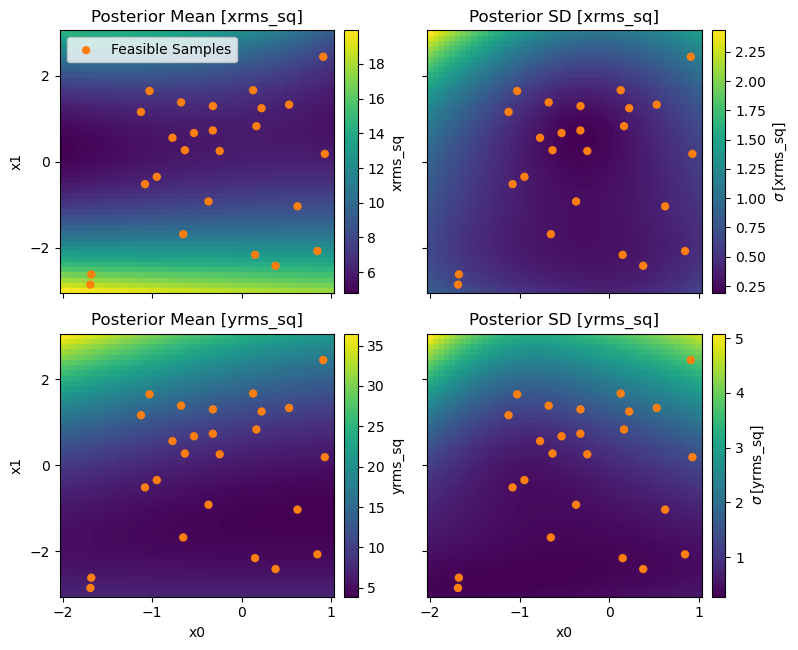

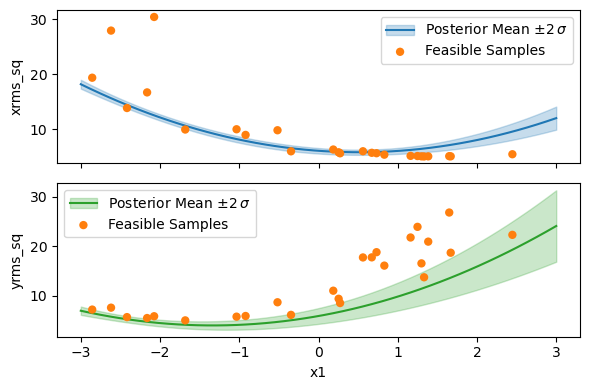

In [15]:
from xopt.generators.bayesian.visualize import visualize_generator_model
optimizer.generator.train_model()
visualize_generator_model(optimizer.generator, 
                          variable_names=['x0','x1'], 
                            reference_point={'x0':torch.tensor([0.]),
                                             'x1':torch.tensor([0.]),
                                            'x2':torch.tensor([0.]),
                                             'x3':torch.tensor([0.]),
                                             'x4':torch.tensor([0.]),
                                             'x5':torch.tensor([0.]),
                                             'x6':torch.tensor([0.]),
                                             'x7':torch.tensor([0.]),
                                             'x8':torch.tensor([0.]),
                                            },
                          show_acquisition=False)
visualize_generator_model(optimizer.generator, 
                          variable_names=['x1'], 
                            reference_point={'x0':torch.tensor([0.]),
                                             'x1':torch.tensor([0.]),
                                            'x2':torch.tensor([0.]),
                                             'x3':torch.tensor([0.]),
                                             'x4':torch.tensor([0.]),
                                             'x5':torch.tensor([0.]),
                                             'x6':torch.tensor([0.]),
                                             'x7':torch.tensor([0.]),
                                             'x8':torch.tensor([0.]),
                                            },
                          show_acquisition=False)

In [16]:
for i in range(100):
    print(i)
    start = time.time()
    optimizer.step()
    print(time.time() - start)

0


C:\Users\dylan\anaconda3\envs\xopt-dev\Lib\site-packages\scipy\optimize\_differentialevolution.py:488: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


tensor([[[-1.9304, -1.9861,  0.7942, -1.6598]]])
tensor([[[ 0.8388, -0.4169, -1.9949, -0.8388]]])
tensor([[[ 0.5113,  0.0458,  0.8811, -1.9900]]])
tensor([[[ 0.6721, -0.7345,  0.9517,  0.7789]]])
tensor([[[-1.9291, -1.1704,  0.5334, -1.7562]]])
tensor([[[ 0.8203, -1.4790,  0.9907, -1.8448]]])
tensor([[[ 0.9249,  0.6233, -1.9998,  0.6802]]])
tensor([[[ 0.9525,  0.1752, -1.9536, -0.8435]]])
tensor([[[-1.9159, -1.9895, -1.5425, -1.8942]]])
tensor([[[-1.9102, -0.3930, -1.2053, -1.1816]]])
5.002582788467407
1


C:\Users\dylan\anaconda3\envs\xopt-dev\Lib\site-packages\scipy\optimize\_differentialevolution.py:488: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


tensor([[[ 0.9438,  0.9336, -1.8751, -1.0041]]])
tensor([[[ 0.8926,  0.3284, -1.9931, -0.9907]]])
tensor([[[ 0.9811, -0.4544, -1.9757, -1.2161]]])
tensor([[[ 0.9318, -0.8350, -1.6788, -0.9972]]])
tensor([[[ 0.9556,  0.8048, -1.0711, -1.3755]]])
tensor([[[ 0.9354, -1.2566,  0.9233, -1.8726]]])
tensor([[[0.8312, 0.7953, 0.9911, 0.9157]]])
tensor([[[ 0.8917,  0.6892, -1.9262, -0.8580]]])
tensor([[[ 0.9716,  0.8153, -1.8869, -0.8733]]])
tensor([[[ 0.9235, -1.9940, -1.8346, -1.8861]]])
5.135256052017212
2


...

tensor([[[ 0.3734, -0.1794, -0.2211, -0.3511]]])
tensor([[[-0.0592, -0.0632,  0.0922,  0.0830]]])
tensor([[[ 0.9714, -1.7303, -0.3593,  0.3177]]])
tensor([[[-0.0558,  0.0866,  0.0056,  0.0435]]])
tensor([[[ 0.0444, -0.0271,  0.1091, -0.0077]]])
tensor([[[ 0.0498, -0.0058,  0.0566, -0.1058]]])
tensor([[[-0.0189,  0.0930, -0.0504, -0.0259]]])
tensor([[[ 0.1117, -0.0117, -0.0785,  0.0375]]])
tensor([[[ 0.0422,  0.0867, -0.0704, -0.0524]]])
tensor([[[ 0.0008,  0.0391,  0.0455, -0.0138]]])
4.853931903839111
98


C:\Users\dylan\anaconda3\envs\xopt-dev\Lib\site-packages\scipy\optimize\_differentialevolution.py:488: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


tensor([[[0.1001, 0.0458, 0.0588, 0.0686]]])
tensor([[[-0.0529,  0.0614, -0.1019, -0.0914]]])
tensor([[[-0.0273, -0.0640,  0.0565,  0.0136]]])
tensor([[[ 0.9855,  0.1403, -0.3221, -0.0127]]])
tensor([[[ 0.1390, -0.0310, -0.0062,  0.0866]]])
tensor([[[-0.0115,  0.0378, -0.0436, -0.0724]]])
tensor([[[ 0.0032,  0.1614,  0.0390, -0.0035]]])
tensor([[[ 0.0124,  0.0109, -0.0284, -0.0073]]])
tensor([[[ 0.0296, -0.0346, -0.0297,  0.0248]]])
tensor([[[-0.0211, -0.0036,  0.1530, -0.0836]]])
4.588597774505615
99


C:\Users\dylan\anaconda3\envs\xopt-dev\Lib\site-packages\scipy\optimize\_differentialevolution.py:488: UserWarning: differential_evolution: the 'vectorized' keyword has overridden updating='immediate' to updating='deferred'
  with DifferentialEvolutionSolver(func, bounds, args=args,


tensor([[[ 0.0649,  0.2327,  0.0286, -0.0333]]])
tensor([[[-0.0053,  0.0659,  0.0810, -0.0280]]])
tensor([[[-0.0217, -0.0066,  0.0146, -0.1057]]])
tensor([[[-0.0668, -0.0706, -0.0550,  0.0378]]])
tensor([[[-0.0218,  0.0083,  0.0088,  0.0167]]])
tensor([[[-0.0453,  0.0121, -0.0669, -0.0576]]])
tensor([[[-0.1085, -0.1216,  0.1961, -0.0409]]])
tensor([[[-0.0170,  0.0304,  0.0564, -0.0513]]])
tensor([[[ 0.8803, -1.9106, -0.6002,  0.6226]]])
tensor([[[-0.0685,  0.0091,  0.0650, -0.0717]]])
4.809927463531494


C:\Users\dylan\anaconda3\envs\xopt-dev\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(


0.46901655197143555


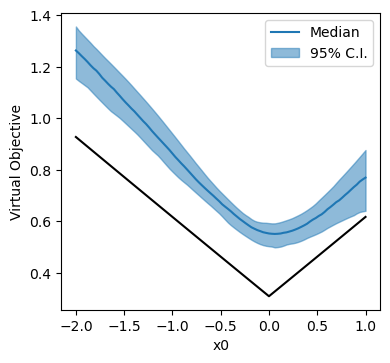

In [17]:
from xopt.generators.bayesian.bax.visualize import visualize_virtual_objective
model = optimizer.generator.train_model()

# for i in range(10):
start = time.time()
fig, ax = visualize_virtual_objective(optimizer.generator, 
                            variable_names=['x0'],
                            reference_point={'x0':torch.tensor([0.]),
                                             'x1':torch.tensor([0.]),
                                            'x2':torch.tensor([0.]),
                                             'x3':torch.tensor([0.]),
                                             'x4':torch.tensor([0.]),
                                             # 'x5':torch.tensor([0.]),
                                             # 'x6':torch.tensor([0.]),
                                             # 'x7':torch.tensor([0.]),
                                             # 'x8':torch.tensor([0.]),
                                            },
                            n_grid=100,
                            n_samples=100,
                            # show_samples=True,
                            kwargs={'use_bmag':False},
                                     )
print(time.time()-start)
x = torch.zeros(100, ndim)
x[:,0] = torch.linspace(*vocs.bounds.T[0], 100)
plt.plot(x[:,0], eval_true_emittance(x, use_bmag=False), c='k')
# plt.ylim(top=0.01)

In [18]:
bmag = algo.results['bmag']
bmag_mean = (bmag[...,0] * bmag[...,1]).sqrt()
bmag_min, bmag_min_id = torch.min(bmag_mean, dim=-1)
plt.plot(x[:,:,0].T,bmag_min.flatten())

IndexError: too many indices for tensor of dimension 2

In [ ]:
bmag.shape

In [ ]:
sample_funcs_list = []
for cpu_model in cpu_models:
    sample_funcs = draw_product_kernel_post_paths(cpu_model, n_samples=10)
    sample_funcs_list += [sample_funcs]

from emitopt.algorithms import unif_random_sample_domain
x0 = unif_random_sample_domain(1000, vocs.bounds.T)
start = time.time()
algo.evaluate_virtual_objective(sample_funcs_list, x0.reshape(10, 100, -1), bounds)
print(time.time()-start)

In [ ]:
# from emitopt.utils import x_tuning_to_dict, get_bax_optimum
# print(optimizer.generator.algorithm_results['x_tuning_best'])
# x_tuning_best = optimizer.generator.algorithm_results['x_tuning_best'].mean(dim=0)
# print(x_tuning_best)
# reference_point = get_bax_optimum(optimizer.generator)
# print(reference_point)
# target_point = x_tuning_to_dict(optimizer.generator, x_tuning = torch.tensor([[0]]))
# print(target_point)

In [ ]:
from emitopt.visualize import plot_virtual_measurement_scan
fig, ax, best_q = plot_virtual_measurement_scan(optimizer, reference_point, n_samples=10)
ax[0].set_ylim(top=1)
ax[1].set_ylim(top=3, bottom=0.9)
ax[0].axhline(0, c='k')